

## Function Approximation

In Reinforcement Learning, **Function Approximation** means:

> Using a parameterized function $\hat{v}(s; \mathbf{w})$ or $\hat{q}(s,a; \mathbf{w})$ to estimate value functions $V(s)$ or $Q(s,a)$ instead of storing exact values for every state or state–action pair.

* The “parameters” $\mathbf{w}$ could be:

  * A **weight vector** in a linear model,
  * The **weights** of a neural network,
  * Parameters of a decision tree, etc.

---

### Motivation 

Older RL methods like **table-lookup TD** or **Monte Carlo** store **one value per state or state–action pair**:

* Works when the **state space is small** and finite.
* Breaks down when:

  * The number of states is huge (e.g., chess: $10^{43}$ states).
  * States are continuous (e.g., robot arm joint positions).
  * **generalization** — learn about one state and apply knowledge to similar states.

Function Approximation solves:

1. **Scalability** — handle millions or infinite possible states.
2. **Generalization** — update one state’s value and improve estimates for similar states automatically.
3. **Compactness** — store parameters instead of a huge table.

---

### Comparision

| Aspect         | Tabular methods                     | Function Approximation                                    |
| -------------- | ----------------------------------- | --------------------------------------------------------- |
| Representation | Table: one value per state/action   | Parameterized function $\hat{v}(s;w)$ or $\hat{q}(s,a;w)$ |
| State space    | Small, discrete                     | Large, possibly continuous                                |
| Generalization | None (only updated state changes)   | Yes — similar states influence each other via parameters  |
| Memory usage   | Proportional to number of states    | Proportional to number of parameters                      |
| Convergence    | Guaranteed under certain conditions | May not converge; depends on approximator and updates     |

---

## **4. Example**

* **Tabular TD(0)**:

  $$
  V(s) \gets V(s) + \alpha \big[ r + \gamma V(s') - V(s) \big]
  $$

  Here $V(s)$ is a table entry — only that specific state gets updated.

* **Linear Approximation TD(0)**:

  $$
  \hat{v}(s; \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s)
  $$

  Update rule:

  $$
  \mathbf{w} \gets \mathbf{w} + \alpha \big[ r + \gamma \hat{v}(s'; \mathbf{w}) - \hat{v}(s; \mathbf{w}) \big] \mathbf{x}(s)
  $$

  Here, changing $\mathbf{w}$ changes the value for **many states at once**.

---

## **5. Advantages over earlier methods**

* **From memorizing → to generalizing**.
* **From discrete → to continuous** handling.
* Essential for **modern deep RL** (DQN, Actor–Critic, PPO, etc.) where neural networks approximate $Q$ or $\pi$.
* Still compatible with TD, Monte Carlo, and DP concepts — you just replace the lookup table with an approximator.



**simple, concrete worked example** for

$$
Q(s,a) \approx \hat{Q}(s,a; \mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s,a)
$$

see exactly what $x(s,a)$ is, how the parameters $w$ are updated, and how generalization happens.



**1. Setup**

* Small **2×2 gridworld**:

```
(0,0)   (0,1)
(1,0)   (1,1)
```

* Actions: `Up (0)`, `Right (1)`, `Down (2)`, `Left (3)`.
* Goal: `(0,1)` gives reward `+1` and ends episode.
* All other transitions give reward `0`.

We’ll approximate $Q(s,a)$ using a **linear model**.



**2. Define feature vector $x(s,a)$**

We need **numeric representation** for state + action.

Example encoding:

* State `(row, col)` → two features: $[ \text{row}, \text{col} ]$
* Action → one-hot of length 4: `[a==0, a==1, a==2, a==3]`
* Add bias term: `1`

So:

$$
x(s,a) = [\text{row}, \text{col}, a_0, a_1, a_2, a_3, 1]
$$

**Example**:

* $s = (1,0), a = 1 $ (`Right`):

  $$
  x(s,a) = [1, 0, 0, 1, 0, 0, 1]
  $$
* $s = (0,1), a = 3 $ (`Left`):

  $$
  x(s,a) = [0, 1, 0, 0, 0, 1, 1]
  $$


**3. Linear Q-function**

Given weight vector $\mathbf{w} \in \mathbb{R}^7$:

$$
\hat{Q}(s,a) = \mathbf{w}^\top x(s,a)
$$

Initially:

$$
\mathbf{w} = [0, 0, 0, 0, 0, 0, 0]
$$

so all Q-values start at 0.



**4. One TD update example (Q-learning)**

Suppose:

* State $s = (1,0)$
* Action $a = 1$ (Right)
* Reward $r = 0$
* Next state $s' = (1,1)$
* From $s'$, best next action’s Q-value = `0.5` (computed from current weights)
* Learning rate $\alpha = 0.1$, discount $\gamma = 1.0$

**Step 1: Compute prediction**

$$
\hat{Q}(s,a) = w^\top x(s,a) = 0 \ (\text{since all w=0 initially})
$$

**Step 2: TD target**

$$
\text{target} = r + \gamma \max_{a'} \hat{Q}(s',a') = 0 + 1.0 \times 0.5 = 0.5
$$

**Step 3: TD error**

$$
\delta = \text{target} - \hat{Q}(s,a) = 0.5 - 0 = 0.5
$$

**Step 4: Weight update**

$$
w \leftarrow w + \alpha \delta \, x(s,a)
$$

Since $x(s,a) = [1,0,0,1,0,0,1]$:

$$
w \leftarrow [0,0,0,0,0,0,0] + 0.1 \times 0.5 \times [1,0,0,1,0,0,1]
$$

$$
w \leftarrow [0.05, 0, 0, 0.05, 0, 0, 0.05]
$$


**5. Effect of generalization**

Now, any $Q(s,a)$ with:

* **row = 1** will share part of its value from $w_0 = 0.05$
* **action = Right** will share part of its value from $w_3 = 0.05$
* **bias term** adds $w_6 = 0.05$ to all state–action pairs.

This means **learning from one (s,a)** updates Q-values for **other similar (s,a)** automatically.


**6. Important**

* $x(s,a)$ encodes numeric features for both state and action.
* In linear approximation, each feature’s weight $w_i$ affects **many** Q-values.
* This is **how function approximation generalizes** beyond tabular methods.


In [23]:
import random 
from dataclasses import dataclass 
from typing import Tuple, Dict, List 
import numpy as np 

In [24]:
class GridWorld:
    def __init__(self, rows:int = 4, cols:int = 4, seed:int = 42):
        self.rows = rows
        self.cols = cols 
        self.start = (0,0)
        self.goal = (self.rows - 1, self.cols - 1)

        self.ACTIONS = {
            0:(-1,0), #up
            1:(0, 1), # right
            2:(1, 0),# down
            3:(0, -1) # left
        }
        self.ACTION_SYMBOLS = {0: "↑", 1: "→", 2: "↓", 3: "←"}
        self.reset()

    def reset(self)->Tuple[int, int]:
        self.s = self.start
        return self.s 

    def step(self, action:int)->Tuple[Tuple[int, int], float, bool]:
        assert action in self.ACTIONS, "unknown action"
        row, col = self.s
        act_row, act_col = self.ACTIONS[action]
        
        next_row, next_col = row + act_row, col + act_col 

        # clip to the grid 
        next_row = max(0, min(self.rows -1, next_row))
        next_col = max(0, min(self.cols-1, next_col))

        next_state = (next_row, next_col)
        done = (next_state == self.goal)
        reward = 0.0 if done else -1.0 #cost 
        self.s = next_state

        return next_state, reward, done

In [25]:
# Given state, and action: a feature vector length: 2 (coord) + 3 (poly) + 4 (action) + 1 (bias) = 10
def feature_vector(state: Tuple[int, int], action:int, rows:int, cols:int)->np.ndarray:
    row, col = state
    row_normalized = row / (rows -1) if rows > 1 else 0.0
    col_normalized = col / (cols -1) if cols > 1 else 0.0
    coord = np.array([row_normalized, col_normalized], dtype=float)
    # adding polynomial for flexibility 
    poly = np.array([row_normalized*0.5, col_normalized*0.5, row_normalized*col_normalized], dtype=float)
    action_one_hot = np.zeros(4, dtype=float)
    action_one_hot[action] = 1.0 
    bias = np.array([1.0], dtype=float)
    return np.concatenate([coord, poly, action_one_hot, bias])


In [26]:
feature_vector((0,1), 1, 4, 4 )

array([0.   , 0.333, 0.   , 0.167, 0.   , 0.   , 1.   , 0.   , 0.   ,
       1.   ])

In [34]:
# Linear Q approximator and ε-greedy policy
class LinearQ:
    def __init__(self, feat_dim:int, alpha:float = 0.05, gamma:float = 1.0, epsilon:float = 0.1, seed:int = 42):
        self.w = np.zeros(feat_dim, dtype=float) # parameters 
        self.alpha = alpha
        self.gamma = gamma 
        self.epsilon = epsilon 

        self.rng = random.Random(seed)

    # W.T @ X -> [s,a] feature vector 
    def q_hat(self, x:np.ndarray) -> float:
        return float(self.w @ x)
    
    # compute action values for give state 
    def q_state_action(self, env:GridWorld, s:Tuple[int, int])->Dict[int, float]:
        # Compute Q for all actions at s (used for greedy/epsilon-greedy)
        return {a: self.q_hat(feature_vector(s, a, env.rows, env.cols)) for a in env.ACTIONS.keys()}
    
    # pick action: epsilon greedy 
    def choose_action(self, env:GridWorld, s:Tuple[int, int])->int:
        if self.rng.random() < self.epsilon:
            return self.rng.choice(list(env.ACTIONS.keys()))
        # choose which action gives best values 
        else:
            q_vals = self.q_state_action(env, s)
            max_q = max(q_vals.values())
            # ties, choose randomly 
            best_actions = [a for a, q in q_vals.items() if q == max_q]
            return self.rng.choice(best_actions)

    def q_learning_update(self, env:GridWorld, s:Tuple[int, int], action:int, reward:float, s_next:Tuple[int, int], done:bool):
        x = feature_vector(s, action, env.rows, env.cols)
        if done:
            target = reward
        else:
            # max_a' Q(s', a') under current weights
            q_next = self.q_state_action(env, s_next)
            target = reward + self.gamma * max(q_next.values())
        
        td_error = target - self.q_hat(x)
        # added later, due to unstable td_error
        td_error = float(np.clip(td_error, -10.0, 10.0))
        # SGD step on squared TD error -> w += alpha * td_error * grad (grad = x for linear model)
        self.w += self.alpha * td_error * x
        return td_error 

    def sarsa_update(self, env:GridWorld, s:Tuple[int, int], action:int, reward:float, s_next:Tuple[int, int], a_next:int, done:bool):
        """
        On-policy SARSA update with linear function approximation.
        target = r + gamma * Q(s', a')  (if not done)
        """
        x = feature_vector(s, action, env.rows, env.cols)
        if done: target = reward
        else:
            # get next
            feat_next = feature_vector(s_next, a_next, env.rows, env.cols)
            target = reward + self.gamma * self.q_hat(feat_next)
        
        # approx current state action value 
        qsa_value = self.q_hat(x)
        td_error = target - qsa_value

        # SGD update w 
        self.w += self.alpha * td_error * x 

        return td_error

In [28]:
def greedy_policy_grid(env: GridWorld, agent: LinearQ) -> List[List[str]]:
    grid = [["." for _ in range(env.cols)] for _ in range(env.rows)]
    for r in range(env.rows):
        for c in range(env.cols):
            s = (r, c)
            if s == env.start:
                grid[r][c] = "S"
            elif s == env.goal:
                grid[r][c] = "G"
            else:
                qvals = agent.q_state_action(env, s)
                best_a = max(qvals, key=qvals.get)
                grid[r][c] = env.ACTION_SYMBOLS[best_a]
    return grid

def print_grid(grid: List[List[str]]):
    for row in grid:
        print(" ".join(row))

In [29]:
#Training loop (Q-learning with linear function approx)
def train_linear_q(env:GridWorld, episodes:int = 5000, alpha:float = 0.05, gamma:float = 1.0, epsilon:float = 0.1, seed:int = 42):
    feat_dim = feature_vector(env.start, 0, env.rows, env.cols).shape[0]
    agent = LinearQ(feat_dim = feat_dim, alpha = alpha, gamma=gamma, epsilon=epsilon, seed=seed)

    ep_returns = []
    ep_td_error = {}
    for ep in range(episodes):
        state = env.reset()
        done = False 
        G = 0.0 
        td_error = []
        while not done:
            action = agent.choose_action(env, state)
            # print(f"action:{action}")
            s_next, reward, done = env.step(action)
            td_error.append(agent.q_learning_update(env, state, action, reward, s_next, done))
            
            state = s_next
            G += reward #gamma is 1
        # average td error 
        ep_td_error[ep] = sum(td_error) / max(1,len(td_error))
        ep_returns.append(G)
    return agent, ep_td_error, ep_returns 

In [30]:
env = GridWorld()
agent, ep_td_error, returns = train_linear_q(env, episodes = 5000, alpha = 0.001, gamma = 0.9, epsilon = 0.2, seed = 42)

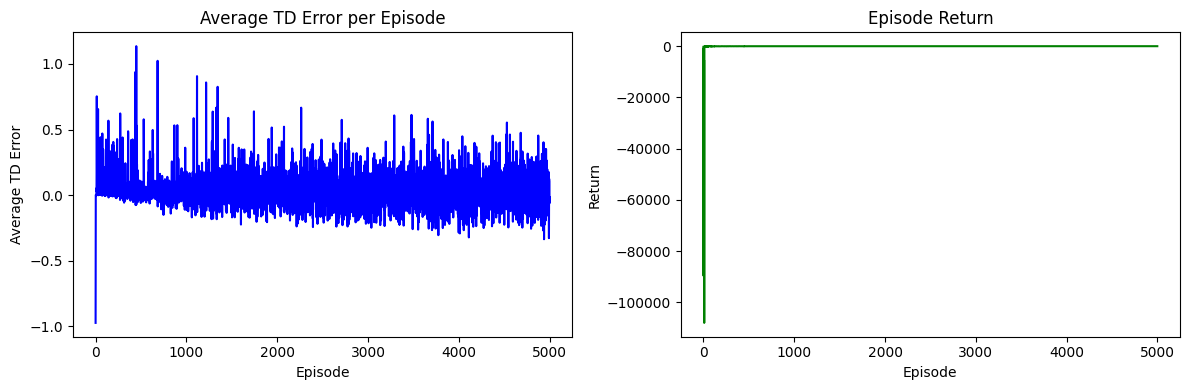

In [31]:
import matplotlib.pyplot as plt 

td_errors = list(ep_td_error.values())
eps = list(ep_td_error.keys())

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot TD error
axs[0].plot(eps, td_errors, color='blue')
axs[0].set_title("Average TD Error per Episode")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Average TD Error")

# Plot returns
axs[1].plot(range(len(returns)), returns, color='green')
axs[1].set_title("Episode Return")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Return")

plt.tight_layout()
plt.show()

In [32]:
grid = greedy_policy_grid(env, agent)
print_grid(grid)

S ↓ ↓ ↓
↓ ↓ ↓ ↓
↓ ↓ ↓ ↓
↓ ↓ ↓ G


In [33]:
np.set_printoptions(precision=3, suppress=True)
print("\nLearned weights w:\n", agent.w)


Learned weights w:
 [ 1.325  1.312  0.662  0.656  4.082 -2.015 -0.795 -0.793 -2.001 -5.604]


In [37]:
def train_linear_sarsa(env:GridWorld, episodes:int = 5000, alpha:float = 0.05, gamma:float = 1.0, epsilon:float = 0.1, seed:int = 42):
    feat_dim = feature_vector(env.start, 0, env.rows, env.cols).shape[0]
    agent = LinearQ(feat_dim = feat_dim, alpha = alpha, gamma=gamma, epsilon=epsilon, seed=seed)

    ep_returns = []
    ep_td_error = {}
    for ep in range(episodes):
        state = env.reset()
        done = False 
        G = 0.0 

        action = agent.choose_action(env, state)

        td_error = []
        
        while not done:
            s_next, reward, done = env.step(action)
            G += reward #gamma is 1

            if not done: 
                a_next = agent.choose_action(env, s_next)
            else:
                a_next = None
        
            td_error.append(agent.sarsa_update(env, state, action, reward, s_next, a_next, done))
            
            state = s_next
            action = a_next if not done else action

        # average td error 
        ep_td_error[ep] = sum(td_error) / max(1,len(td_error))
        ep_returns.append(G)
    return agent, ep_td_error, ep_returns 

In [43]:
new_env = GridWorld()
agent, ep_td_error, returns = train_linear_sarsa(env, episodes = 5000, alpha = 0.001, gamma = 0.9, epsilon = 0.2, seed = 42)

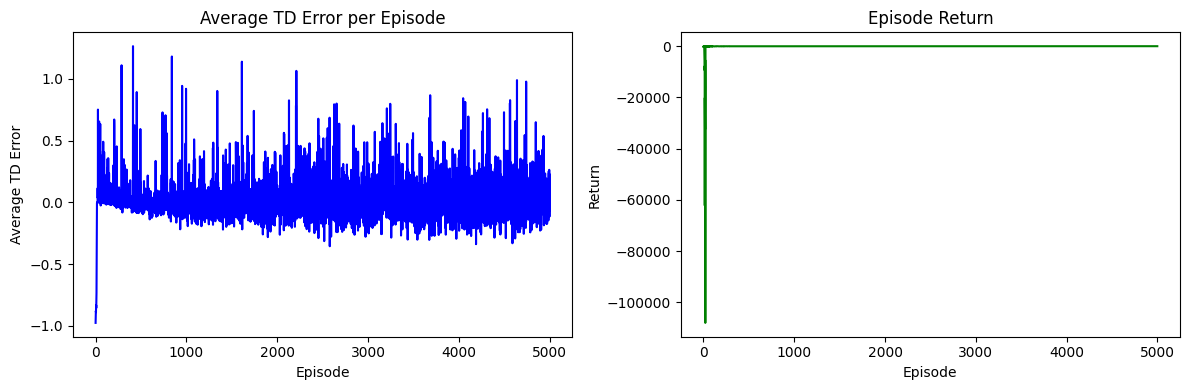

In [44]:
td_errors = list(ep_td_error.values())
eps = list(ep_td_error.keys())

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Plot TD error
axs[0].plot(eps, td_errors, color='blue')
axs[0].set_title("Average TD Error per Episode")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Average TD Error")

# Plot returns
axs[1].plot(range(len(returns)), returns, color='green')
axs[1].set_title("Episode Return")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Return")

plt.tight_layout()
plt.show()

In [45]:
np.set_printoptions(precision=3, suppress=True)
print("\nSARSA Learned weights w:\n", agent.w)


SARSA Learned weights w:
 [ 1.206  1.221  0.603  0.611  5.422 -2.357 -1.138 -1.133 -2.385 -7.013]


In [46]:
grid = greedy_policy_grid(env, agent)
print_grid(grid)

S ↓ ↓ ↓
↓ ↓ ↓ ↓
↓ ↓ ↓ ↓
↓ ↓ ↓ G
